In [1]:
from mastu import HSV
import numpy as np
# import MDSplus as mds
from  scipy.linalg import eigh, solve_banded

In [2]:
import matplotlib.pyplot as plt

In [3]:
%matplotlib widget

In [4]:
r_end = 1.8
sys_err = 5
# sys_err = 20

In [5]:
shotn = 49091
I0 = 260
I1 = I0 + 1
J0 = 53
J1 = 215
# J1 = 235
tind = 500
dtind = 5
# nr = 405 # * 2.5 still
nrtimes = 2.5

In [7]:
def getRz(I0, I1, J0, J1):
    data = np.load('/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/rba_viewing.npz')
    R = data['Rmin'][I0,J0:J1]
    z = data['zmin'][I0,J0:J1]
    return R, z

R, z = getRz(I0, I1, J0, J1)
nr = int(len(R) * nrtimes)

In [8]:
### load the data
raw_data, time = HSV.get(shotn)
frames = np.mean(raw_data[I0:I1,J0:J1,tind-dtind:tind+dtind], axis=-1)

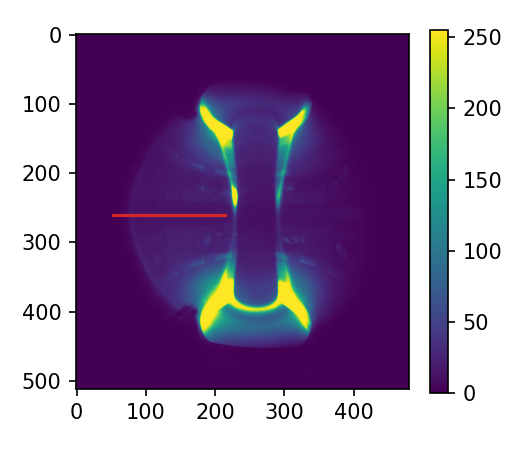

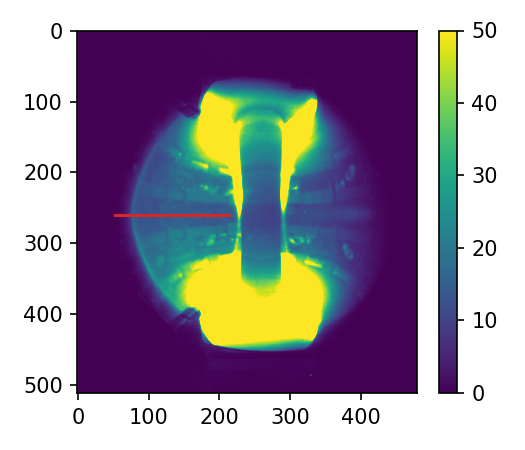

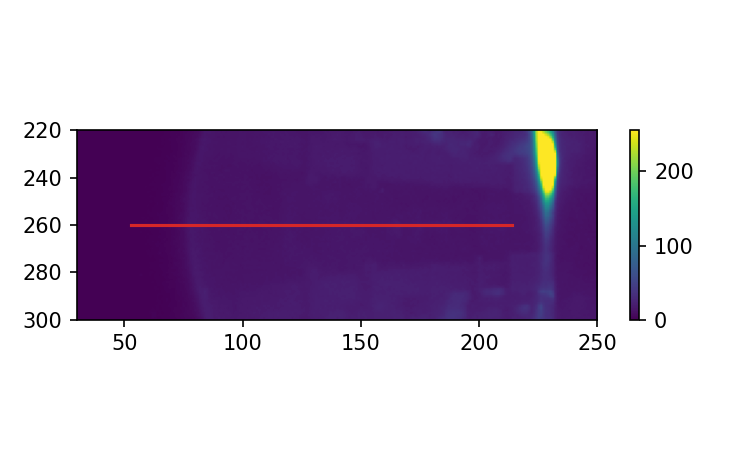

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1))
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1), vmin=0, vmax=50)
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1), vmin=0, 
              vmax=raw_data[220:301,30:251,tind-dtind:tind+dtind].mean(axis=-1).max())
fig.colorbar(ims, ax=ax, shrink=0.47)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
ax.set_xlim([30,250])
ax.set_ylim([300,220])
plt.tight_layout()

In [10]:
### say which channels are good based off zeros
# good_chans = np.ones(raw_data.shape[1]).astype(bool)
good_chans = np.ones(len(R)).astype(bool)
### loaded R already
lfs_r = R[good_chans]
### flip R
lfs_r = np.flip(lfs_r)
if r_end:
    lfs_r = np.insert(lfs_r, len(lfs_r), r_end)
### number of R values
nch_lfs = len(lfs_r)

### this is for calibration! and for the error on the calibration. 
calf = np.ones(lfs_r.shape)
calfErr = np.ones(lfs_r.shape)*sys_err/100

### creating the response matrix
R_tg_virtual = lfs_r
#center of mass of the LOS, assume z=0
R_tg = R_tg_virtual
Z_tg = np.zeros_like(R_tg)
### upper and lower R values
lfs_min = R_tg[0]
lfs_max = R_tg[-1]
### gives resolution of emissivity grid (325), and makes Rgrid
R_grid = np.linspace(lfs_min, lfs_max, nr)

### returns a 2D array with dimensions of the grid and the original viewing
### locations. It's the different between the R location of the two.
### if any of them it is negative, it replaces it with a zero
### then it does it again but with only 1 space difference, and then it does
### the difference between them and multiplies it by 2?
dL = 2*(np.sqrt(np.maximum((R_grid[1:])**2-R_tg_virtual[:,None]**2,0))
       -np.sqrt(np.maximum( R_grid[:-1]**2-R_tg_virtual[:,None]**2,0)))
# dL = dL # no need to sum over spot size
print('end of load_geometry')

end of load_geometry


In [11]:
### load the data
# raw_data, _ = HSV.get(shotn)
data = np.mean(raw_data[I0:I1,J0:J1,tind-dtind:tind+dtind], axis=-1)
data = data[:,good_chans]
data = np.flip(data, axis=1)
### add a zero at desired r_end value
if r_end:
    _zeros = np.zeros(len(data[:,0]))[:,None]
    data = np.concatenate((data, _zeros), axis=1)
### number of views
n_los = len(data[0])
tvec = np.array([0.1])

### assume the first index is last good one
last_good_ind = 0
count = 0
### iterate over the time
for tt in range(len(tvec)):
    ### always select the highest R value that isn't one we appended 
    min_data = data[tt,-2] # because there's a 0 by default at the end
    ### if this point is positive, make this the last good time index
    if min_data >= 0:
        last_good_ind = tt

    ### if this point is negative, I want to add on the maximum value from the 
    ### last good time index to all the points in this current one?
    ### I don't really understand why though
    elif min_data < 0:
        count += 1
#         plt.figure()
#         plt.plot(lfs_r, raw_data[tt])
        data[tt,:-1] += np.max(data[last_good_ind])

In [12]:
# offset = slice(570, len(time))
# n_smooth = 1
# nt, nch = data.shape
# data_low = data
# tvec_low = tvec
# nt = nt//n_smooth*n_smooth
# ### I don't really know what this is doing
# tvec_low = tvec[:nt].reshape(-1,n_smooth).mean(1)

# data_low = data[:nt].reshape(-1,n_smooth, nch).mean(1)-background#raw_data[I0:I1,J0:J1,570:].mean(0)
# error_low = np.zeros_like(data_low)+np.std(data_low[tvec_low<0],0)[None,:]/3
# ### guess errorbarss from the variation between neighboring channels
# ind1 = np.r_[1,0:n_los-1]
# ind2 = np.r_[  1:n_los  ,n_los-2]
# # the ind1 and ind2, basically shift data_low up and down by one to find the average
# # value of the neighboring channels. That is then subtracting from the original array
# # to get the average difference from neighboring hcannels
# error_low += np.std(
#     np.diff(
#         data_low - (data_low[:,ind1] + data_low[:,ind2]) / 2, axis=0
#     ),
#     axis=0) / np.sqrt(2)

In [13]:
print('these are done')

these are done


In [14]:
### the index slice that goes before t=0
offset = slice(0, tvec.searchsorted(0))
### sampling time
# dt = (tvec[-1]-tvec[0])/(len(tvec)-1)
### smooth is not done here, hence = 1
n_smooth = 1
### data shapes
nt, nch = data.shape
### copy of the data and time
# data_low = data
tvec_low = tvec
### adjust nt if need be
nt = nt//n_smooth*n_smooth
### I don't really know what this is doing
tvec_low = tvec[:nt].reshape(-1,n_smooth).mean(1)
### nor do I know what this is really doing,
### but it is removing an offset
### estimate noise from the signal before the plasma
### for error_low
if (offset.stop - offset.start) == 0:
    data_low = data[:nt].reshape(-1,n_smooth, nch).mean(1)
    error_low = np.zeros_like(data_low)
else:
    data_low = data[:nt].reshape(-1,n_smooth, nch).mean(1)-data[offset].mean(0)
    error_low = np.zeros_like(data_low)+np.std(data_low[tvec_low<0],0)[None,:]/3
    ### guess errorbarss from the variation between neighboring channels
    ind1 = np.r_[1,0:n_los-1]
    ind2 = np.r_[  1:n_los  ,n_los-2]
    # the ind1 and ind2, basically shift data_low up and down by one to find the average
    # value of the neighboring channels. That is then subtracting from the original array
    # to get the average difference from neighboring hcannels
    error_low += np.std(
        np.diff(
            data_low - (data_low[:,ind1] + data_low[:,ind2]) / 2, axis=0
        ),
        axis=0) / np.sqrt(2)
    
# remove offset estimated from the edge most detector
offset_time = data_low[:,[-1]]
data_low -= offset_time
# make sure that zero value is within errorbars when data are negative
error_low = np.maximum(error_low, -data_low)

### this converts the data to the calibrated data
data = data_low * calf#[ph/m^2s]
err  = np.sqrt(\
            (error_low*calf)**2+\
            (data_low*calfErr)**2
           ) #[ph/m^2s] # laggnerf
tvec = tvec_low #[s]
scale = np.median(data) #just a normalisation to aviod calculation with so huge exponents
if np.isclose(scale, 0.):
    scale = np.median(data[1:])

nt = len(tvec)
print('end of load_data')

end of load_data


In [15]:
print(data)
print(data.shape)
print(err)
print(err.shape)
print(scale)

[[14.8 14.5 13.7 15.8 14.7 14.6 15.3 15.9 15.3 16.4 15.6 15.3 15.6 14.
  13.  13.9 12.8 11.8 12.8 13.  12.  13.2 13.7 14.2 14.7 14.5 14.5 16.9
  15.6 15.3 16.3 16.1 17.5 16.7 15.9 15.8 14.9 14.  16.6 17.9 16.6 15.4
  15.8 16.1 14.9 13.9 14.8 15.9 19.5 18.7 18.  16.2 16.4 15.6 15.2 14.8
  14.  13.8 15.9 14.8 14.8 14.1 14.4 15.2 15.  15.  15.7 15.5 15.5 15.3
  15.9 16.  14.7 15.6 15.3 14.9 14.5 14.3 15.4 15.2 15.1 14.8 15.  15.1
  14.  14.7 14.3 13.9 13.7 14.2 15.1 14.5 15.1 15.7 15.5 15.6 14.8 15.
  14.8 13.9 13.1 12.7 14.3 12.9 13.9 13.4 13.8 12.9 12.  12.4 13.1 13.8
  12.5 13.1 13.3 12.5 12.4 12.8 12.4 12.7 12.2 13.2 13.  12.3 12.5 11.5
  12.9 12.7 11.7 12.8 14.7 14.4 14.4 14.3 15.5 15.3 15.8 13.7 12.   9.7
   8.1  7.5  6.1  5.1  3.7  3.2  3.3  2.1  2.2  2.8  2.3  2.2  1.1  1.4
   0.8  0.6  0.7  0.2  0.4  0.2  0.5  0.2  0. ]]
(1, 163)
[[0.74  0.725 0.685 0.79  0.735 0.73  0.765 0.795 0.765 0.82  0.78  0.765
  0.78  0.7   0.65  0.695 0.64  0.59  0.64  0.65  0.6   0.66  0.685 0.71
  0.7

In [16]:
from scipy.signal import argrelmax

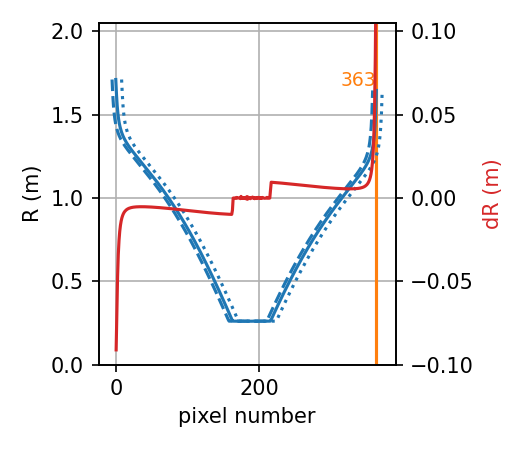

In [17]:
R0, z0 = getRz(I0, I1, 0, None)
RmaxInds = argrelmax(R0)[0]
R0 = R0[RmaxInds[0]:RmaxInds[-1]+1]
z0 = z0[RmaxInds[0]:RmaxInds[-1]+1]
x0 = np.arange(len(R0))
dR = np.diff(R0)
dx0 = x0[:-1] + 0.5

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(x0, R0, zorder=3)
ax.plot(x0-5.2, R0, '--', c='C0', zorder=3)
ax.plot(x0+8.1, R0, ':', c='C0', zorder=3)
ax.text(x0[-1], R0[-1], x0[-1], ha='right', va='bottom', c='C1', rotation=0, fontsize=9)
ax.set_xlabel('pixel number')
ax.set_ylabel('R (m)')
ax.grid()
ax.vlines(x0[-1], ymin=0, ymax=R0.max()*1.2, colors='C1', zorder=2)
ax.set_ylim([0, R0.max()*1.2])

ax2 = ax.twinx()
ax2.plot(dx0, dR, c='C3')
ax2.set_ylim([-0.1,0.10529096846583391])
ax2.set_ylabel('dR (m)', c='C3')

plt.tight_layout()

In [18]:
dSlice = (slice(I0,I1), slice(J0,J1), slice(0,len(time)))

In [19]:
dSlice

(slice(260, 261, None), slice(53, 215, None), slice(0, 1125, None))

In [20]:
dSlice[:-1]

(slice(260, 261, None), slice(53, 215, None))

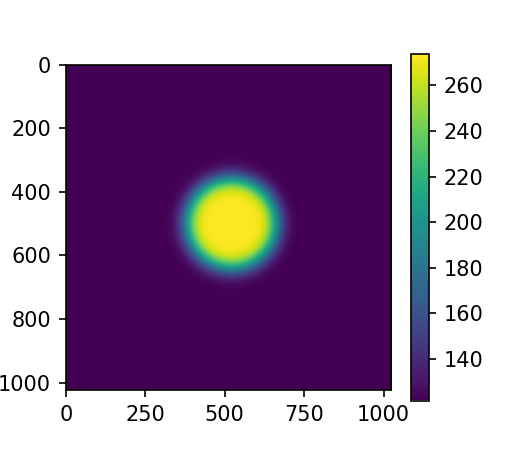

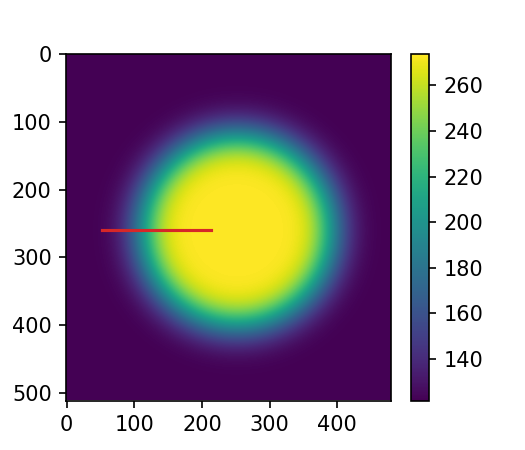

In [21]:
from mastu import HSV
vignette = HSV.vignette()
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(vignette)
fig.colorbar(ims, ax=ax)

vignette = HSV.transform(vignette, shotn)
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(vignette)
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')

vignette /= vignette.max()
vignette0 = vignette[I0,RmaxInds[0]:RmaxInds[-1]+1]
vignette = vignette[I0,J0:J1]

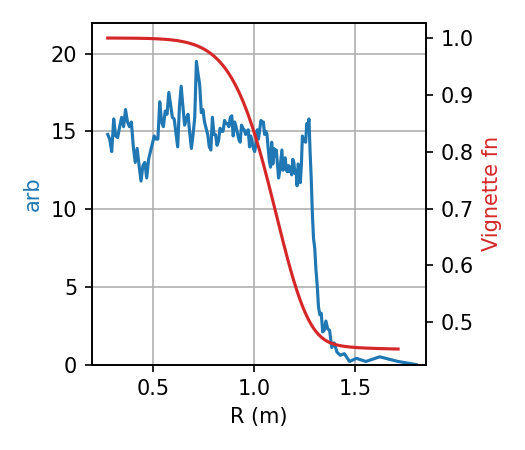

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R_tg, data[0])
ax.set_xlabel('R (m)')
ax.set_ylabel('arb', c='C0')
ax.grid()
ax.set_xlim([0.2,1.85])
ax.set_ylim([0.,22.])

ax2 = ax.twinx()
ax2.plot(R, vignette, c='C3')
ax2.set_ylabel('Vignette fn', c='C3')

plt.tight_layout()

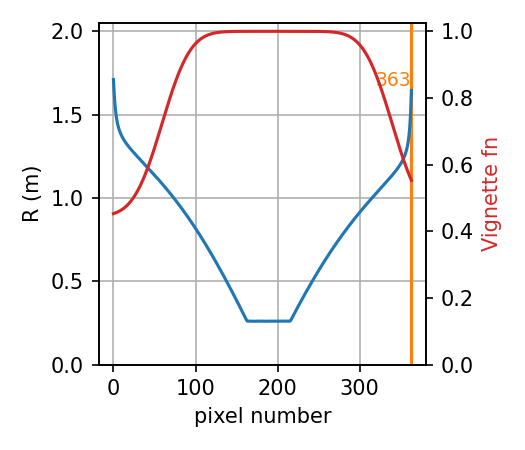

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(x0, R0, zorder=3)
ax.plot(x0, R0+5.2, '--', zorder=3)
ax.text(x0[-1], R0[-1], x0[-1], ha='right', va='bottom', c='C1', rotation=0, fontsize=9)
ax.set_xlabel('pixel number')
ax.set_ylabel('R (m)')
ax.grid()
ax.vlines(x0[-1], ymin=0, ymax=R0.max()*1.2, colors='C1', zorder=2)
ax.set_ylim([0, R0.max()*1.2])

ax2 = ax.twinx()
ax2.plot(vignette0, c='C3')
ax2.set_ylabel('Vignette fn', c='C3')
ax2.set_ylim([0, R0.max()*1.2/2.])

plt.tight_layout()

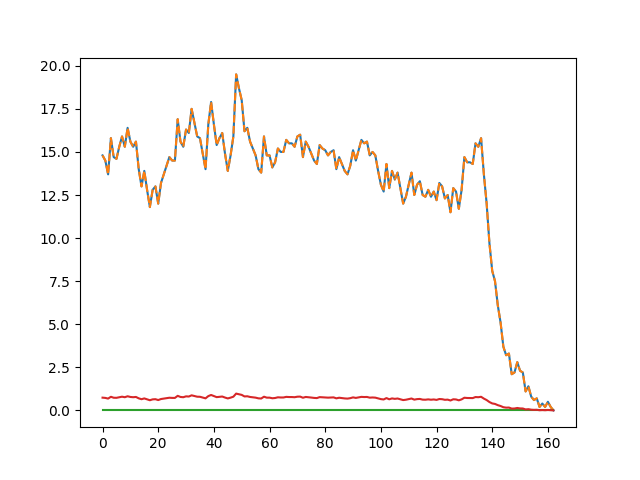

In [24]:
plt.figure()
plt.plot(data[0])
plt.plot(data_low[0], '--')
plt.plot(error_low[0])
plt.plot(err[0])

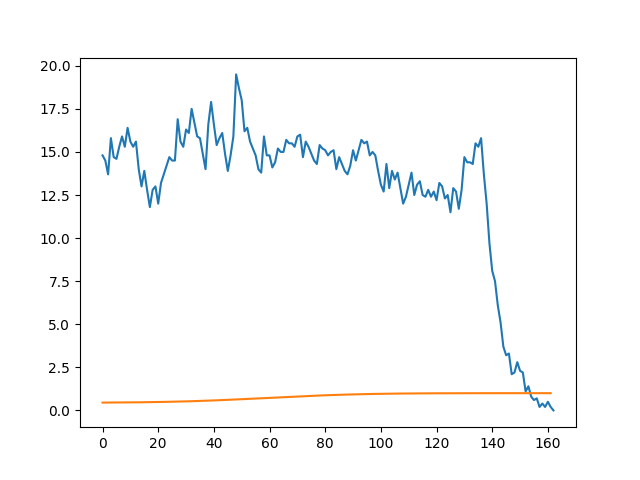

In [25]:
plt.figure()
plt.plot(data[0])
plt.plot(vignette)

In [26]:
n_blocks = len(tvec)

In [27]:
### no idea what these are, they're just there

# defined independently for LFS and HFS
reg_level_guess = .7, .6
reg_level_min = .4, .4

nfisher = 4

iside = 0
lfs_contribution = [0]

In [28]:
### biased_edges is used as True
def regul_matrix(biased_edges=True):
    #regularization band matrix
    bias = .1 if biased_edges else 1e-5
    ### (3 x R_grid-1), all 1s
    D = np.ones((3,nr-1))
    ### make row 1 all negative 2s
    D[1,:] *= -2
    ### last in middle row is bias value
    D[1,-1] = bias
    ### middle row, first element and second last element are negative 1s
    D[1,[0,nr-3]] = -1
    ### last row, elements -2 and -3 are set to zero
    D[2,[-2,-3]] = 0
    return D

In [29]:
def GCV(g, prod, S, U):
    #generalized crossvalidation
    w = 1. / (1. + np.exp(g) / S**2)
    ndets = len(prod)
    return (np.sum((((w - 1) * prod))**2) + 1) / ndets / (1 - np.mean(w))**2

In [30]:
def FindMin(F, x0, dx0, prod, S, U, tol=0.01):
    #stupid but robust minimum searching algorithm.
    fg = F(x0, prod, S, U)
    while abs(dx0) > tol:
        fg2 = F(x0 + dx0, prod, S, U)
        if fg2 < fg:
            fg = fg2
            x0 += dx0
            continue
        else:
            dx0 /= -2.

    return x0, np.log(fg2)

In [31]:
D = regul_matrix(biased_edges=True)
### a bunch of empty arrays
### len(time) x len(R_grid)-1
y = np.zeros((nt, nr-1))
y_err = np.zeros((nt, nr-1))

### len(time)
chi2lfs = np.zeros(nt)
gamma_lfs = np.zeros(nt)

### shape of data
backprojection = np.zeros_like(data)

### indices for time
itime = np.arange(nt)
### splits the time indices up into the number of blocks
### but it is normally just length of time for n_blocks
tinds = np.array_split(itime, n_blocks)

for ib, tind in enumerate(tinds):
#     print('ib={}, tind={}'.format(ib,tind))
    ### where the mean of the error, and the error, are zero
    ### averaging across time
    mean_err_zero_inds = np.where(err[tind].mean(0) == 0)
    err_zero_inds = np.where(err[tind] == 0)
    
    ### no idea what T is, it's this dL thing divided by error
    ### and then multiplied by scale
    T = dL / err[tind].mean(0)[:,None] * scale
    ### mean of the data in this time divided by the mean of the error
    mean_d = data[tind].mean(0) / err[tind].mean(0)
    ### data divided by error
    d = data[tind] / err[tind]
    
    ### replace infinities and nans with 0
    T[mean_err_zero_inds] = 0
    mean_d[mean_err_zero_inds] = 0
    d[err_zero_inds] = 0
    
    ### load of ones for now
    W = np.ones(nr-1)
    ### some slices, zero uptp # channels, and the # R_grid
    ind_los = slice(0,nch_lfs)
    ind_space = slice(0,nr-1)
    
    ### makes Q the same length as the ind_los slice
    Q = np.linspace(0, 1, ind_los.stop - ind_los.start)
    
    
    
    for ifisher in range(nfisher):        
        ### multiply tridiagonal regularisation operator by a diagonal weight matrix W
        WD = np.copy(D)

        ### seems redundent, as W is all ones
        WD[0,1:]*=W[:-1]
        WD[1]*=W
        WD[2,:-1]*=W[1:]
        
        ### transpose the band matrix
        DTW = np.copy(WD)
        DTW[0,1:],DTW[2,:-1] = WD[2,:-1],WD[0,1:]
        
        
        #####    solve Tikhonov regularization (optimised for speed)
        ### this is from scipy, and is solving a banded matrix?
        H = solve_banded((1,1), DTW, T[ind_los,ind_space].T, overwrite_ab=True, check_finite=False)
        #fast method to calculate U,S,V = svd(H.T) of rectangular matrix
        LL = np.dot(H.T, H)
        #### also from scipy
        S2, U = eigh(LL, overwrite_a=True, check_finite=False, lower=True)
        S2 = np.maximum(S2, 1) #singular values S can be negative due to numerical uncertainty
        
        mean_p = np.dot(mean_d[ind_los] - np.mean(lfs_contribution, 0), U)
        
        #guess for regularisation - estimate quantile of log(S^2)
        g0 = np.interp(reg_level_guess[iside], Q, np.log(S2))
        
        if ifisher == nfisher -1:
            #last step - find optimal regularisation
            S = np.sqrt(S2)

            g0, log_fg2 = FindMin(GCV, g0 , 1, mean_p, S, U.T) #slowest step
            #avoid too small regularisation when min of GCV is not found

            gmin = np.interp(reg_level_min[iside], Q, np.log(S2))
            g0 = max(g0, gmin)

            #filtering factor
            w = 1. / (1. + np.exp(g0) / S2)

            V = np.dot(H, U / S)
            V = solve_banded((1,1), WD, V, overwrite_ab=True, overwrite_b=True, check_finite=False)
        else:
            #filtering factor
            w = 1. / (1. + np.exp(g0) / S2)

            #calculate y without evaluating V explicitly
            Y = np.dot(H, np.dot(U / S2, w * mean_p))
            #final inversion of mean solution , reconstruction
            Y = solve_banded((1,1), WD, Y, overwrite_ab=True, overwrite_b=True, check_finite=False)

            #weight matrix for the next iteration
            W = 1 / np.maximum(Y, 1e-10)**.5
            
    p = np.dot(d[:,ind_los] - lfs_contribution, U)
    Y = np.dot((w/S) * p, V.T)
#     print(fit.shape, fit)
    print(p.shape, p)
    print(w.shape, w)
    print(U.T.shape, U.T)

    backprojection[tind,ind_los] = fit = np.dot(p*w, U.T) + lfs_contribution
    chi2 = np.sum((d[:,ind_los] - fit)**2, 1) / np.size(fit, 1)
    gamma = np.interp(g0, np.log(S2), Q)

    chi2lfs[tind] = chi2
    gamma_lfs[tind] = gamma

    y[tind,ind_space] = Y
    #correction for under/over estimated data uncertainty
    y_err[tind,ind_space] = np.sqrt(np.dot(V**2, (w / S)**2))#*chi2[:,None])
    
    backprojection[tind] *= err[tind].mean(0)

y *= scale
y_err *= scale

R_grid_b = (R_grid[1:]+ R_grid[:-1])/2

/tmp/ipykernel_29174/2284450337.py:29: RuntimeWarning: invalid value encountered in divide
  T = dL / err[tind].mean(0)[:,None] * scale
/tmp/ipykernel_29174/2284450337.py:31: RuntimeWarning: invalid value encountered in divide
  mean_d = data[tind].mean(0) / err[tind].mean(0)
/tmp/ipykernel_29174/2284450337.py:33: RuntimeWarning: invalid value encountered in divide
  d = data[tind] / err[tind]


(1, 163) [[-4.79677600e-02  3.37486268e-01  5.66361696e-01  2.36842796e+00
   9.75728129e-01 -1.03516156e+00  0.00000000e+00 -1.69498691e+00
   1.10657806e+00 -1.62707546e+00 -1.00935073e+00  9.99036357e-01
   1.55449761e+00  7.03351046e-01  1.33979536e+00  2.70225094e-01
   5.32257898e-01  2.15049218e-01  9.36114425e-01  1.01877208e+00
   7.56957525e-01 -4.49602254e-01 -9.99190518e-01 -7.79697418e-02
  -8.07590661e-01 -5.97709936e-01  2.04080384e-01  3.45674655e-01
   4.38000348e-01 -6.54559289e-01 -5.15272328e-01 -1.00686222e+00
  -5.57083794e-01  1.01803583e-01 -1.19508829e+00 -3.04085390e-02
  -1.00363081e+00 -3.74008158e-01 -2.69864252e-01  4.94555110e-01
   5.29403262e-01  1.15641240e+00  5.20390404e-01 -4.41987874e-01
  -9.70713781e-01  2.30107212e-01  3.77026440e-01 -4.27490985e-01
   6.22039680e-01  8.32406707e-01 -6.77882020e-01 -2.51334901e-01
  -3.11835473e-01 -2.57302829e-01 -5.02101174e-01  1.29579038e+00
   2.85610128e-01 -1.24763965e+00  1.13093100e-01  3.14574572e-01
 

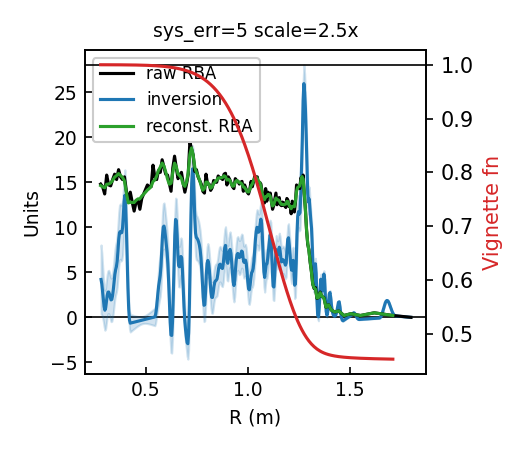

In [32]:
xplot = [0.2,1.875]
title = f'sys_err={sys_err} scale={nrtimes:.1f}x'

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R_tg, data[0], '-', c='k', zorder=3, label='raw RBA')
ax.plot(R_grid_b, y[0], '-', c='C0', zorder=2, label='inversion')
ax.fill_between(R_grid_b, y[0]-y_err[0], y[0]+y_err[0], color='C0', alpha=0.2, zorder=2)
ax.plot(R[::-1], backprojection[0,:-1], c='C2', zorder=4, label='reconst. RBA')

ax.set_xlim(xplot)
ax.plot(xplot, [0.,0.], '-k', lw=0.8, zorder=1)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Units', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=False)
ax.set_title(title, fontsize=9)

# plt.savefig('/home/sthoma/Documents/Plots/MU04/Inversions/' + 
#             title.replace(' ', '_').replace('=', '_') + '.png')

ax2 = ax.twinx()
ax2.plot(R, vignette, c='C3')
ax2.set_ylabel('Vignette fn', c='C3')
ax2.plot(xplot, [1.,1.], '-k', lw=0.8, zorder=1)
plt.tight_layout()

# np.savez('/home/sthoma/Documents/Results/MU04/Inversions/' + 
#         title.replace(' ', '_').replace('=', '_') + '.npz', 
#         R=R, 
#         frame=frames[0], 
#         R_grid=R_grid, 
#         y=y[0], 
#         y_err=y_err[0], 
#         backprojection=backprojection, 
#         )

In [33]:
import my_funcs as mf

-------------------Loading module Divertor-------------------
-------------------Loading module Utilities-------------------
kk_cz couldnt be imported (SyntaxError)
dd couldnt be imported


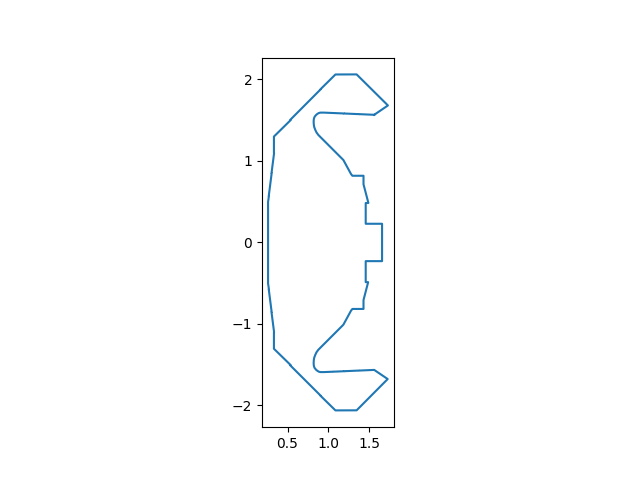

In [34]:
Rlim, zlim = mf.getLimiter()
fig, ax = plt.subplots(1, 1)
ax.plot(Rlim, zlim)
ax.set_aspect('equal')

In [35]:
Rlim.min()

0.260841

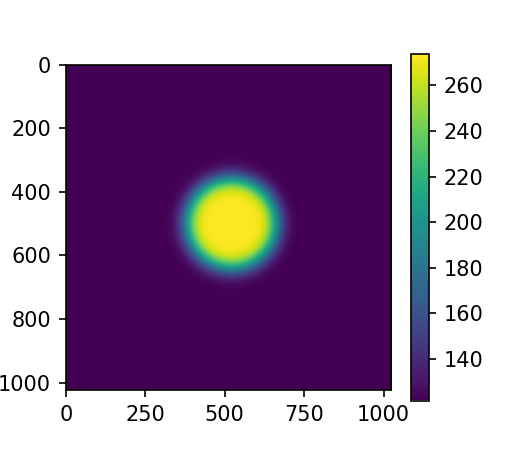

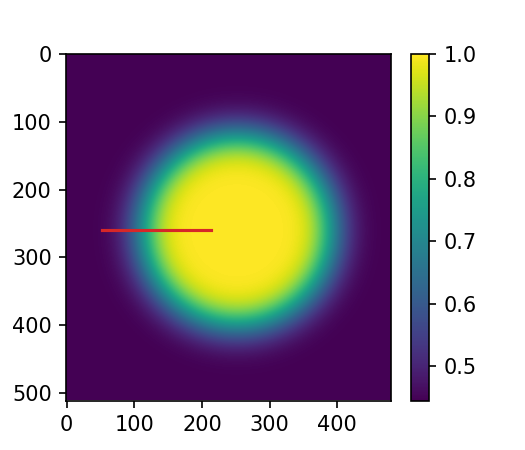

In [36]:
V = HSV.vignette()
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(V)
fig.colorbar(ims, ax=ax)

V = HSV.transform(V, shotn)
V /= V.max()
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(V)
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')


# vignette0 = vignette[I0,RmaxInds[0]:RmaxInds[-1]+1]
# vignette = vignette[I0,J0:J1]

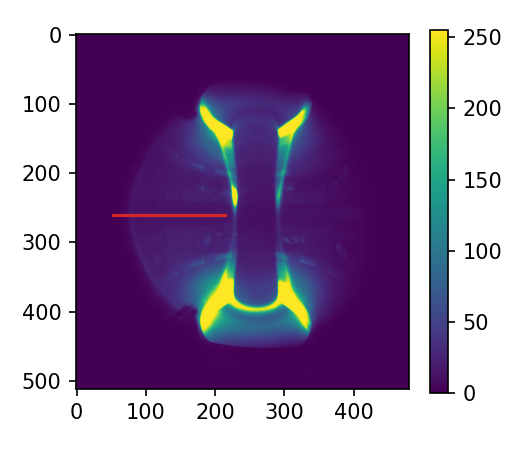

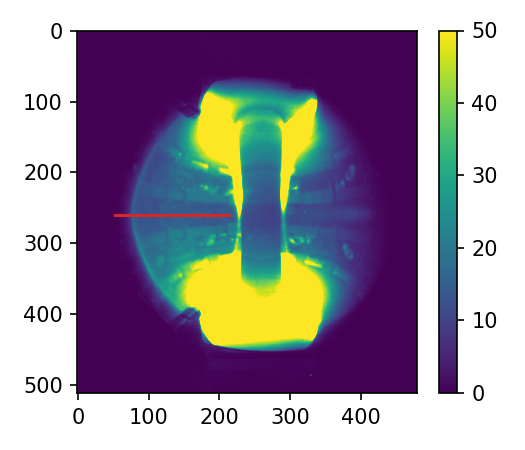

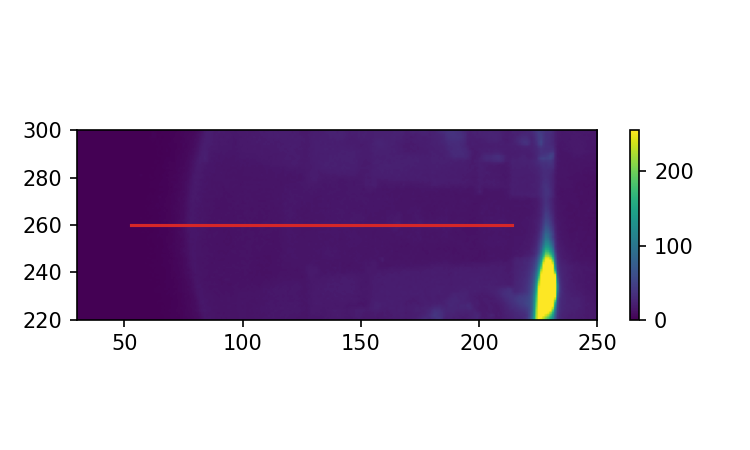

In [37]:
tind = 500
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1))
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1), vmin=0, vmax=50)
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1), vmin=0, 
              vmax=raw_data[220:301,30:251,tind-dtind:tind+dtind].mean(axis=-1).max())
fig.colorbar(ims, ax=ax, shrink=0.47)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
ax.set_xlim([30,250])
ax.set_ylim([220,300])
plt.tight_layout()

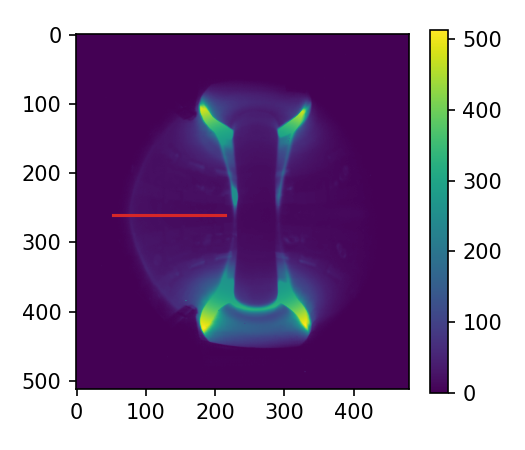

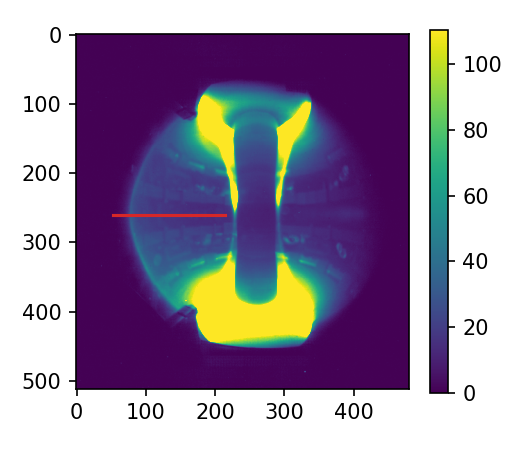

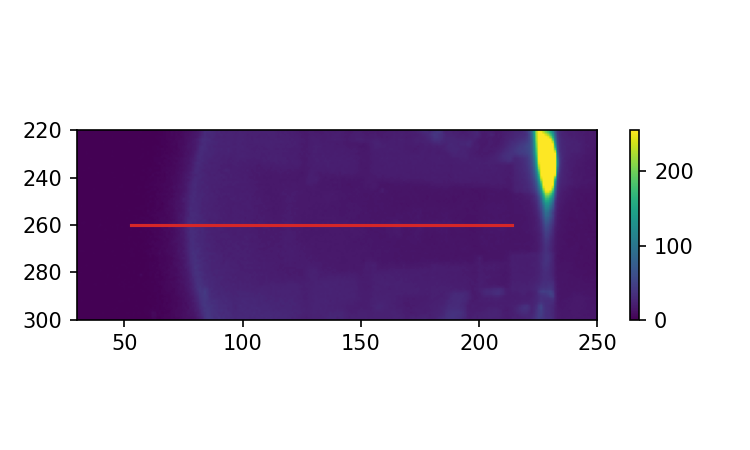

In [38]:
tind = 500

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1) / V)
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1) / V, vmin=0, vmax=50/vignette.min())
fig.colorbar(ims, ax=ax)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(5,3), dpi=150)
ims=ax.imshow(raw_data[...,tind-dtind:tind+dtind].mean(axis=-1) / V, vmin=0, 
              vmax=(raw_data[220:301,30:251,tind-dtind:tind+dtind].mean(axis=-1) / V[220:301,30:251]).max())
fig.colorbar(ims, ax=ax, shrink=0.47)
ax.plot(np.arange(J0,J1), np.zeros_like(np.arange(J0,J1))+I0, '-', c='C3')
ax.set_aspect('equal')
ax.set_xlim([30,250])
ax.set_ylim([300,220])
plt.tight_layout()

In [39]:
raw_data.shape

(512, 480, 1125)

In [40]:
mydata = raw_data[I0:I1, J0:J1][0].T
mydata = mydata[400:600]
mydata.shape
myav = np.zeros_like(mydata).astype(float)
kernel = np.ones(10) / 10.
for i in range(0, 162):
    myav[:,i] = np.convolve(mydata[:,i], kernel, mode='same')

In [41]:
myav[100]

array([ 0.2,  0.5,  0.2,  0.4,  0.2,  0.7,  0.6,  0.8,  1.4,  1.1,  2.2,
        2.3,  2.8,  2.2,  2.1,  3.3,  3.2,  3.7,  5.1,  6.1,  7.5,  8.1,
        9.7, 12. , 13.7, 15.8, 15.3, 15.5, 14.3, 14.4, 14.4, 14.7, 12.8,
       11.7, 12.7, 12.9, 11.5, 12.5, 12.3, 13. , 13.2, 12.2, 12.7, 12.4,
       12.8, 12.4, 12.5, 13.3, 13.1, 12.5, 13.8, 13.1, 12.4, 12. , 12.9,
       13.8, 13.4, 13.9, 12.9, 14.3, 12.7, 13.1, 13.9, 14.8, 15. , 14.8,
       15.6, 15.5, 15.7, 15.1, 14.5, 15.1, 14.2, 13.7, 13.9, 14.3, 14.7,
       14. , 15.1, 15. , 14.8, 15.1, 15.2, 15.4, 14.3, 14.5, 14.9, 15.3,
       15.6, 14.7, 16. , 15.9, 15.3, 15.5, 15.5, 15.7, 15. , 15. , 15.2,
       14.4, 14.1, 14.8, 14.8, 15.9, 13.8, 14. , 14.8, 15.2, 15.6, 16.4,
       16.2, 18. , 18.7, 19.5, 15.9, 14.8, 13.9, 14.9, 16.1, 15.8, 15.4,
       16.6, 17.9, 16.6, 14. , 14.9, 15.8, 15.9, 16.7, 17.5, 16.1, 16.3,
       15.3, 15.6, 16.9, 14.5, 14.5, 14.7, 14.2, 13.7, 13.2, 12. , 13. ,
       12.8, 11.8, 12.8, 13.9, 13. , 14. , 15.6, 15

In [42]:
taverage = 8
if taverage:
    print('yes')
else:
    print('no')

yes


In [43]:
data.shape

(1, 163)

In [44]:
I0, I1, J0, J1

(260, 261, 53, 215)

/tmp/ipykernel_29174/2447448067.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)


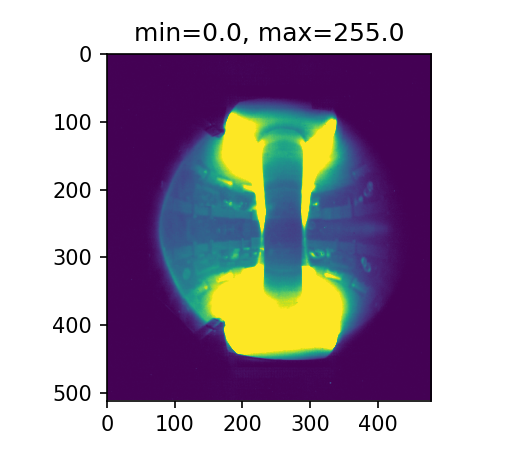

In [45]:
frame = raw_data[...,tind-dtind:tind+dtind].mean(axis=-1)

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.imshow(frame, vmin=0, vmax=50.)
ax.title.set_text(f'min={frame.min()}, max={frame.max()}')

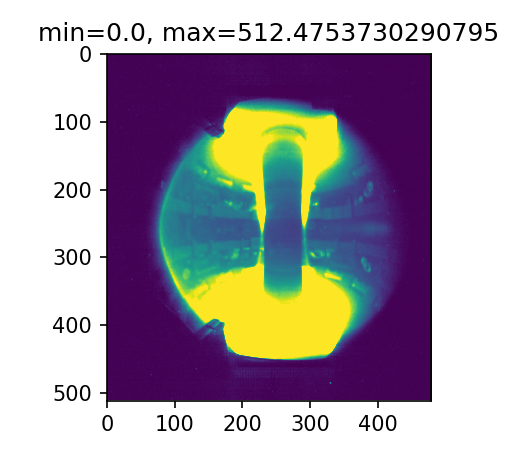

In [46]:
V0 = HSV.transform(HSV.vignette(), shotn)
V0 /= V0.max()
frame0 = frame / V0

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.imshow(frame0, vmin=0, vmax=50.)
ax.title.set_text(f'min={frame0.min()}, max={frame0.max()}')

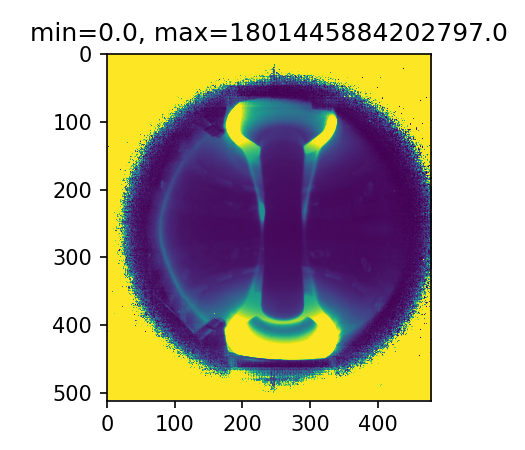

In [47]:
Vtest = HSV.transform(HSV.vignette(amp=1., offset=0.), shotn)
Vframe = frame / Vtest

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.imshow(Vframe, vmin=0., vmax=500.)
ax.title.set_text(f'min={Vframe.min()}, max={Vframe.max()}')

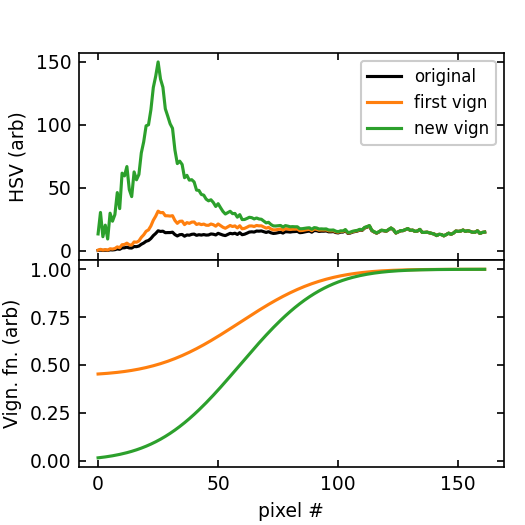

In [48]:
myslice = (slice(I0,I1), slice(J0,J1))

x = np.arange(J1-J0)

fig, ax = plt.subplots(2, 1, figsize=(3.5,3.5), dpi=150, sharex=True, )
plt.subplots_adjust(hspace=0)
ax[0].plot(x, frame[myslice][0], c='k', label='original')
ax[0].plot(x, frame0[myslice][0], c='C1', label='first vign')
ax[0].plot(x, Vframe[myslice][0], c='C2', label='new vign')
# ax[1].plot(x, frame[myslice][0], c='C0', label='original')
ax[1].plot(x, V0[myslice][0], c='C1', label='first vign')
ax[1].plot(x, Vtest[myslice][0], c='C2', label='new vign')
ax[0].legend(fancybox=1, framealpha=1, fontsize=8)

ax[0].set_ylabel('HSV (arb)', fontsize=9)
ax[1].set_ylabel('Vign. fn. (arb)', fontsize=9)
ax[1].set_xlabel('pixel #', fontsize=9)

ax[0].tick_params(axis="both", which='both', labelsize=9, direction='in', 
                  left=True, bottom=True, right=True, top=True)
ax[1].tick_params(axis="both", which='both', labelsize=9, direction='in', 
                  left=True, bottom=True, right=True, top=True)

ax[0].set_position([0.15, 0.505, 0.81, 0.395])
ax[1].set_position([0.15, 0.11, 0.81, 0.395])

In [47]:
# ne = np.array([
#     5.00E+07, 1.00E+08, 2.00E+08, 5.00E+08, 1.00E+09, 2.00E+09, 5.00E+09, 1.00E+10,
#     2.00E+10, 5.00E+10, 1.00E+11, 2.00E+11, 5.00E+11, 1.00E+12, 2.00E+12, 5.00E+12,
#     1.00E+13, 2.00E+13, 5.00E+13, 1.00E+14, 2.00E+14, 5.00E+14, 1.00E+15, 2.00E+15,
# ]) * 1e6 # convert to m^-3
# Te = np.array([
#     2.00E-01, 3.00E-01, 5.00E-01, 7.00E-01, 1.00E+00, 1.50E+00, 2.00E+00, 3.00E+00,
#     5.00E+00, 7.00E+00, 1.00E+01, 1.50E+01, 2.00E+01, 3.00E+01, 5.00E+01, 7.00E+01,
#     1.00E+02, 1.50E+02, 2.00E+02, 3.00E+02, 5.00E+02, 7.00E+02, 1.00E+03, 1.50E+03,
#     2.00E+03, 3.00E+03, 5.00E+03, 7.00E+03, 1.00E+04, 
# ])

In [48]:
# fig, ax = plt.subplots(1, 1, figsize=(3.35,2.8), dpi=150)
# ax.plot(ne, 'o', c='C0', mfc='None')
# ax.set_ylabel('ne (m^-3)', c='C0')
# ax2 = ax.twinx()
# ax2.plot(Te, '^', c='C1', mfc='None')
# ax2.set_ylabel('Te (eV)', c='C1')
# ax.title.set_text(f'len(ne)={len(ne):.0f}, len(Te)={len(Te):.0f}, ')
# plt.tight_layout()

# fig, ax = plt.subplots(1, 1, figsize=(3.35,2.8), dpi=150)
# ax.plot(np.log10(ne), 'o', c='C0', mfc='None')
# ax.set_ylabel('log10(ne) (m^-3)', c='C0')
# ax2 = ax.twinx()
# ax2.plot(np.log10(Te), '^', c='C1', mfc='None')
# ax2.set_ylabel('log10(Te) (eV)', c='C1')
# ax.title.set_text(f'len(ne)={len(ne):.0f}, len(Te)={len(Te):.0f}, ')
# plt.tight_layout()

In [49]:
# fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
# for i in range(13, 22):
#     ax.plot(Te, np.log10(flat[i]))
    

In [50]:
# fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
# pcm=ax.pcolormesh(np.log10(Te[:-3]), ne[10:], np.log10(flat[10:,:-3]))
# fig.colorbar(pcm, ax=ax)